In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/delivery_data.csv")

df["delay_ratio"] = (
    df["actual_time"] /
    df["osrm_time"]
)

df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,delay_ratio
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111,1.200000
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714,1.428571
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000,1.550000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000,1.545455


In [3]:
G = nx.DiGraph()

In [4]:
for _, row in df.iterrows():

    source = row["source_center"]
    destination = row["destination_center"]

    delay = row["delay_ratio"]

    G.add_edge(
        source,
        destination,
        weight=delay
    )

In [5]:
print("Number of Nodes:", G.number_of_nodes())

print("Number of Edges:", G.number_of_edges())

Number of Nodes: 1657
Number of Edges: 2783


In [7]:
print(G)

DiGraph with 1657 nodes and 2783 edges


In [8]:
degree_centrality = nx.degree_centrality(G)

In [9]:
top_degree = (
    pd.DataFrame(
        degree_centrality.items(),
        columns=["center", "score"]
    )
    .sort_values(
        "score",
        ascending=False
    )
)

top_degree.head(20)

,center,score
43,IND000000ACB,0.056763
7,IND562132AAA,0.042874
65,IND160002AAC,0.036836
3,IND421302AAG,0.035024
81,IND501359AAE,0.034420
123,IND712311AAA,0.027778
136,IND110037AAM,0.027174
4,IND411033AAA,0.025966
21,IND131028AAB,0.024155
25,IND600056AAB,0.021739


In [10]:
betweenness = nx.betweenness_centrality(
    G,
    k=100,
    seed=42
)

In [11]:
top_betweenness = (
    pd.DataFrame(
        betweenness.items(),
        columns=["center", "score"]
    )
    .sort_values(
        "score",
        ascending=False
    )
)

top_betweenness.head(20)

,center,score
43,IND000000ACB,0.233031
7,IND562132AAA,0.147130
81,IND501359AAE,0.087299
123,IND712311AAA,0.086146
3,IND421302AAG,0.082671
4,IND411033AAA,0.067823
25,IND600056AAB,0.063064
114,IND781018AAB,0.054837
65,IND160002AAC,0.053767
21,IND131028AAB,0.045894


In [12]:
top_50 = list(
    df["source_center"]
    .value_counts()
    .head(50)
    .index
)

In [13]:
subgraph = G.subgraph(top_50)

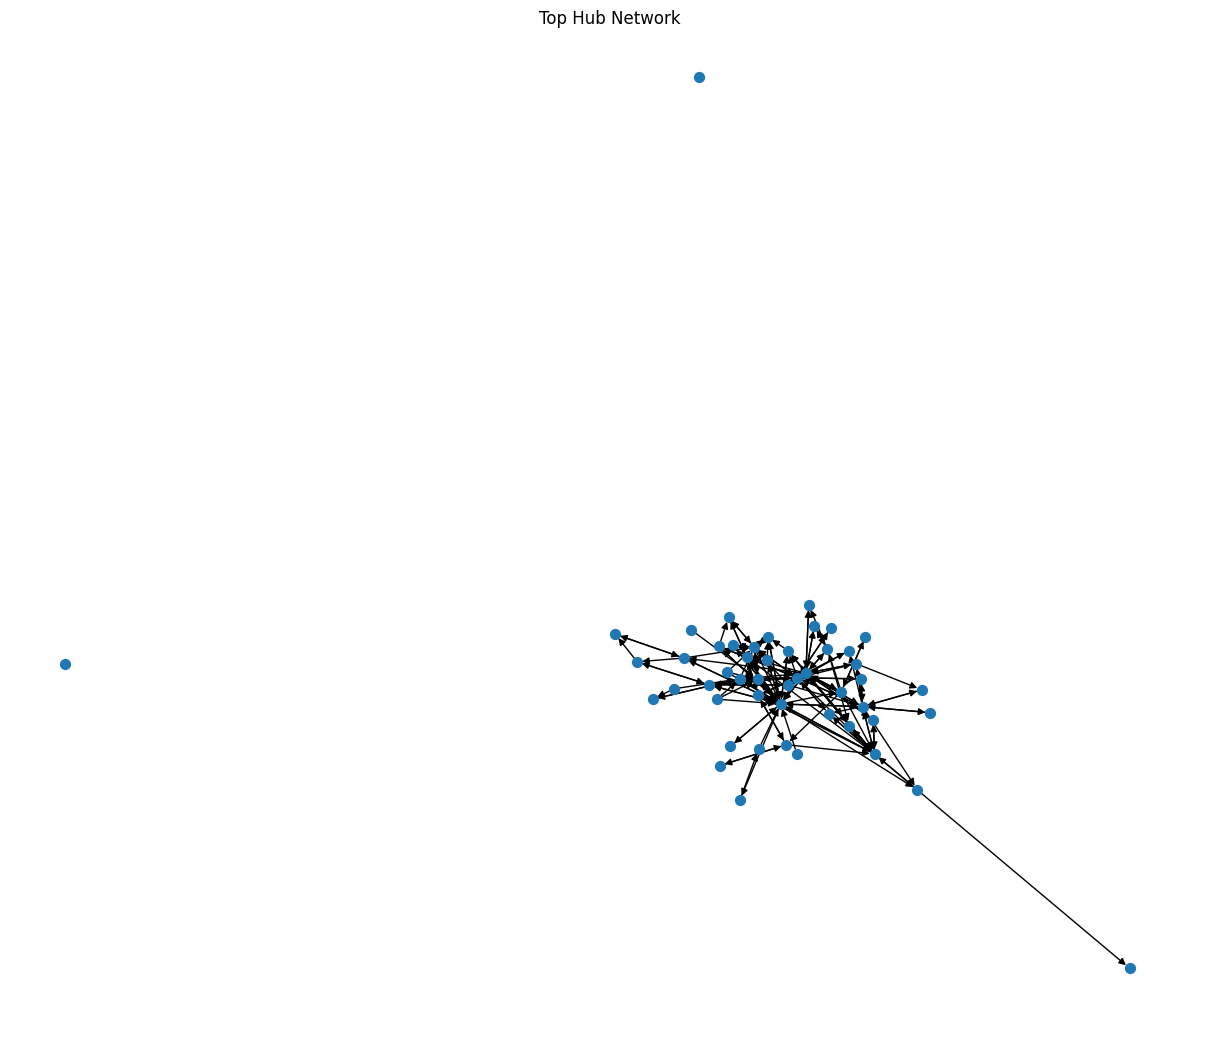

In [14]:
plt.figure(figsize=(12,10))

pos = nx.spring_layout(
    subgraph,
    seed=42
)

nx.draw(
    subgraph,
    pos,
    with_labels=False,
    node_size=50
)

plt.title(
    "Top Hub Network"
)

plt.show()

In [15]:
source_degree = dict

In [16]:
betweenness = nx.betweenness_centrality(
    G,
    k=100,
    seed=42
)

df["source_betweenness"] = (
    df["source_center"]
    .map(betweenness)
)

In [17]:
df[["source_center", "source_betweenness"]].head()

,source_center,source_betweenness
0,IND388121AAA,0.000435
1,IND388121AAA,0.000435
2,IND388121AAA,0.000435
3,IND388121AAA,0.000435
4,IND388121AAA,0.000435


In [18]:
df["destination_betweenness"] = (
    df["destination_center"]
    .map(betweenness)
)

In [19]:
df[[
    "destination_center",
    "destination_betweenness"
]].head()

,destination_center,destination_betweenness
0,IND388620AAB,0.0
1,IND388620AAB,0.0
2,IND388620AAB,0.0
3,IND388620AAB,0.0
4,IND388620AAB,0.0


In [20]:
pagerank = nx.pagerank(G)

In [21]:
df["source_pagerank"] = (
    df["source_center"]
    .map(pagerank)
)

In [22]:
df[["source_center", "source_pagerank"]].head()

,source_center,source_pagerank
0,IND388121AAA,0.000605
1,IND388121AAA,0.000605
2,IND388121AAA,0.000605
3,IND388121AAA,0.000605
4,IND388121AAA,0.000605


In [23]:
df["destination_pagerank"] = (
    df["destination_center"]
    .map(pagerank)
)

In [24]:
df[[
    "destination_center",
    "destination_pagerank"
]].head()

,destination_center,destination_pagerank
0,IND388620AAB,0.000633
1,IND388620AAB,0.000633
2,IND388620AAB,0.000633
3,IND388620AAB,0.000633
4,IND388620AAB,0.000633


In [25]:
new_features = [
    "source_degree",
    "destination_degree",
    "source_betweenness",
    "destination_betweenness",
    "source_pagerank",
    "destination_pagerank"
]

df[new_features].head()

KeyError: "['source_degree', 'destination_degree'] not in index"

In [26]:
df.to_csv(
    "../data/processed/graph_features.csv",
    index=False
)

In [27]:
df.columns.tolist()

['data',
 'trip_creation_time',
 'route_schedule_uuid',
 'route_type',
 'trip_uuid',
 'source_center',
 'source_name',
 'destination_center',
 'destination_name',
 'od_start_time',
 'od_end_time',
 'start_scan_to_end_scan',
 'is_cutoff',
 'cutoff_factor',
 'cutoff_timestamp',
 'actual_distance_to_destination',
 'actual_time',
 'osrm_time',
 'osrm_distance',
 'factor',
 'segment_actual_time',
 'segment_osrm_time',
 'segment_osrm_distance',
 'segment_factor',
 'delay_ratio',
 'source_betweenness',
 'destination_betweenness',
 'source_pagerank',
 'destination_pagerank']

In [28]:
source_degree = dict(G.degree())

df["source_degree"] = (
    df["source_center"]
    .map(source_degree)
)

In [29]:
destination_degree = dict(G.degree())

df["destination_degree"] = (
    df["destination_center"]
    .map(destination_degree)
)

In [30]:
df[[
    "source_degree",
    "destination_degree"
]].head()

,source_degree,destination_degree
0,2,2
1,2,2
2,2,2
3,2,2
4,2,2


In [31]:
new_features = [
    "source_degree",
    "destination_degree",
    "source_betweenness",
    "destination_betweenness",
    "source_pagerank",
    "destination_pagerank"
]

df[new_features].head()

,source_degree,destination_degree,source_betweenness,destination_betweenness,source_pagerank,destination_pagerank
0,2,2,0.000435,0.0,0.000605,0.000633
1,2,2,0.000435,0.0,0.000605,0.000633
2,2,2,0.000435,0.0,0.000605,0.000633
3,2,2,0.000435,0.0,0.000605,0.000633
4,2,2,0.000435,0.0,0.000605,0.000633


In [32]:
df.to_csv(
    "../data/processed/graph_features.csv",
    index=False
)

In [2]:
recommend_route(
    G,
    "IND000000ACB",
    "IND562132AAA"
)

NameError: name 'recommend_route' is not defined